# Agreement metrics

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from swiss_uhi_lcd import plot_utils

sns.set_style("whitegrid")

In [ ]:
ts_df_filepath = "../data/raw/parallel-2025-int.csv"

# optional subset of station models to show
# station_models = None
station_models = ["Abilium_2", "Barani", "Decentlab", "Koalasense", "Onset_big"]

col_wrap = 5

dst_agreement_table_filepath = "../reports/tables/agreement-metrics.csv"
dst_fig_bland_altman_filepath = "../reports/figures/bland-altman-plot.pdf"
savefig_kwargs = {"dpi": 300, "bbox_inches": "tight"}

In [ ]:
ts_df = (
    pd.read_csv(ts_df_filepath, parse_dates=["time"])
    .set_index("time")
    .resample("h")
    .mean()
)

all_station_models = [col for col in ts_df.columns if col != "Prof"]
if station_models is None:
    station_models = all_station_models
else:
    station_models = [sm for sm in station_models if sm in all_station_models]

ts_df = ts_df[["Prof"] + station_models]
ts_df.head()

,Prof,Abilium_2,Barani,Decentlab,Koalasense,Onset_big
time,,,,,,
2025-07-27 00:00:00,15.533333,15.053025,15.200000,NaN,15.133333,15.334000
2025-07-27 01:00:00,15.450000,14.956448,15.100000,NaN,14.983333,15.278667
2025-07-27 02:00:00,15.366667,14.934641,15.083333,NaN,14.950000,15.191000
2025-07-27 03:00:00,15.416667,14.929745,15.100000,NaN,14.983333,15.211000
2025-07-27 04:00:00,14.883333,14.434399,14.616667,NaN,14.466667,14.907667


## Agreement metrics table

In [ ]:
records = []
for model in station_models:
    paired = ts_df[["Prof", model]].dropna()
    err = paired[model] - paired["Prof"]
    n = len(err)
    records.append(
        {
            "LCD model": model,
            "N": n,
            "MBE [K]": err.mean(),
            "MdBE [K]": err.median(),
            "MAE [K]": err.abs().mean(),
            "RMSE [K]": np.sqrt(np.mean(err**2)),
            "IQR [K]": err.quantile(0.75) - err.quantile(0.25),
        }
    )

agreement_df = pd.DataFrame(records)
display(agreement_df.round(4))
agreement_df.round(4).to_csv(dst_agreement_table_filepath, index=False)

,LCD model,N,MBE [K],MdBE [K],MAE [K],RMSE [K],IQR [K]
0,Abilium_2,1224,0.0659,-0.0202,0.4322,0.5490,0.7584
1,Barani,1224,-0.1803,-0.2333,0.3047,0.3717,0.3667
2,Decentlab,802,0.1746,-0.0769,0.5271,0.6742,1.0258
3,Koalasense,1224,-0.1878,-0.2167,0.3203,0.3870,0.3833
4,Onset_big,1224,0.0777,0.0418,0.2554,0.3516,0.4106


## Bland-Altman plot

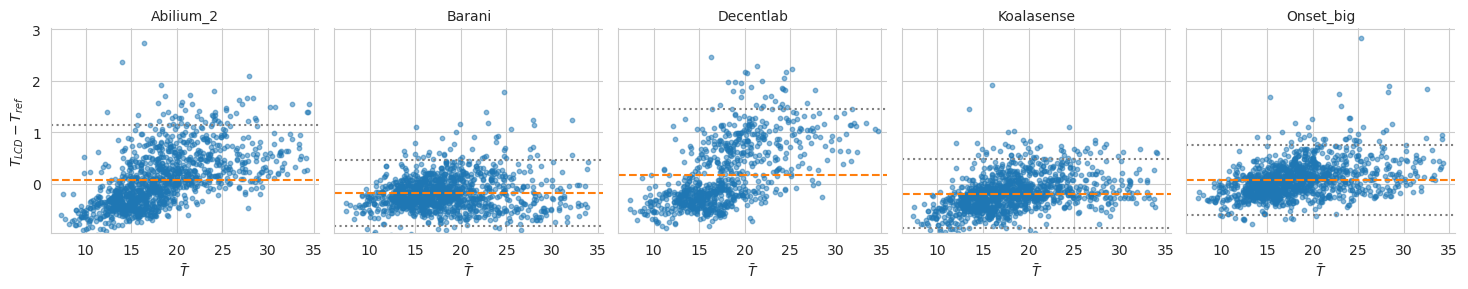

In [ ]:
T_label = r"$\bar{T}$"
g = sns.FacetGrid(
    ts_df.drop(columns="Prof")
    .rename_axis(columns="station_id")
    .stack()
    .rename(T_label)
    .reset_index(level="station_id")
    .sort_values("station_id"),
    col="station_id",
    col_wrap=col_wrap,
)


def bland_altman(y, color=None, **kwargs):
    """Bland-Altman plot."""
    ax = plt.gca()
    plot_utils.bland_altman_plot(y, ts_df["Prof"].loc[y.index], ax=ax, **kwargs)


mean_line_color = sns.color_palette()[1]
g.map(
    bland_altman,
    T_label,
    scatter_kwds=dict(alpha=0.5, s=10),
    mean_line_kwds=dict(color=mean_line_color),
    limit_lines_kwds=dict(color="gray"),
)
g.set_titles("{col_name}")
g.figure.savefig(dst_fig_bland_altman_filepath, **savefig_kwargs)